In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from AssignmentI.helper import (
    running_average_forecast,
    lag_forecast,
    exp_smoothing_forecast,
    metrics,
    running_trend_forecast,
    random_walk_plus_drift_forecast,
    estimate_alpha_exponential_smoothing
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

## (a) - (c)

In [3]:
# Define AR(1) Forecast via Regression
def ar1_forecast(y):

    y = np.asarray(y)
    f = np.full(len(y), np.nan)

    for t in range(2, len(y)):
        y_past = y[:t]
        y_dep = y_past[1:]
        y_lag = y_past[:-1].reshape(-1, 1)

        model = LinearRegression().fit(y_lag, y_dep)

        mu = model.intercept_
        phi = model.coef_[0]

        # manual AR(1) forecast, rounded to 2 decimals
        f[t] = mu + phi * y_past[-1]

    return f

# AR(1) debug function printing parameter estimates and one-step-ahead forecasts based on the last observation.
def ar1_forecast_debug(y):

    y = np.asarray(y)
    f = np.full(len(y), np.nan)

    for t in range(2, len(y)):
        y_past = y[:t+1]
        y_dep = y_past[1:]
        y_lag = y_past[:-1].reshape(-1, 1)

        model = LinearRegression().fit(y_lag, y_dep)

        mu = round(model.intercept_, 2)
        phi = round(model.coef_[0], 2)

        # manual AR(1) forecast, rounded to 2 decimals
        f[t] = round(mu + phi * y_past[-1], 2)

        print(f"y_past[-1] = {y_past[-1]}")

        print(f"t = {t}")
        print(f"mu = {mu}")
        print(f"phi = {phi}")
        print(f"forecast = {f[t]}")
        print("-" * 40)

    return f

In [4]:
# MA(1) objective: minimize an in-sample one-step-ahead forecast error statistic (default: SSE)
def ma1_objective(params, y, criterion="SSE"):
    mu, theta = params
    eps = 0.0
    errs = []

    for val in y:
        err = val - (mu + theta * eps)
        errs.append(err)
        eps = err

    errs = np.asarray(errs, dtype=float)

    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def ma1_forecast(y, criterion="SSE"):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)

    for t in range(3, len(y)):
        y_past = y[:t]

        res = minimize(
            ma1_objective,                 # objective function (SSE/MSE/MAE) implied by the MA(1) recursion
            [np.mean(y_past), 0.1],        # initial parameter guess [mu, theta]
            args=(y_past, criterion),      # pass the sample and selected criterion to the objective
            bounds=[(None, None), (-1, 1)] # parameter bounds: mu unbounded, theta constrained to [-1, 1]
        )

        mu, theta = res.x

        eps = 0.0
        for val in y_past:
            err = val - (mu + theta * eps)
            eps = err

        f[t] = mu + theta * eps

    return f

In [5]:
# ARMA(1,1) objective: minimize an in-sample one-step-ahead forecast error statistic (default: SSE)
def arma11_objective(params, y, criterion="SSE"):
    c, phi, theta = params
    eps = 0.0
    errs = []

    for t in range(1, len(y)):
        f_t = c + phi * y[t - 1] + theta * eps
        err = y[t] - f_t
        errs.append(err)
        eps = err

    errs = np.asarray(errs, dtype=float)

    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def arma11_forecast(y, criterion="SSE"):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)

    for t in range(3, len(y)):
        y_past = y[:t]

        res = minimize(
            arma11_objective,                       # objective function (SSE/MSE/MAE) implied by the ARMA(1,1) recursion
            [np.mean(y_past) * 0.1, 0.5, 0.1],      # initial parameter guess [c, phi, theta]
            args=(y_past, criterion),               # pass the sample and selected criterion to the objective
            bounds=[(None, None), (-1, 1), (-1, 1)] # parameter bounds: c unbounded, phi in [-1,1], theta in [-1,1]
        )

        c, phi, theta = res.x

        eps = 0.0
        for i in range(1, len(y_past)):
            f_i = c + phi * y_past[i - 1] + theta * eps
            eps = y_past[i] - f_i

        f[t] = c + phi * y_past[-1] + theta * eps

    return f

### Gasoline Sales 1
This section evaluates the performance of AR(1), MA(1), and ARMA(1,1) models against the benchmark methods from Assignment I using the GasolineSales1 dataset.

In [6]:
# Load Gasoline Sales 1
df_gas1 = pd.read_excel('GasolineSales1.xlsx')
y_gas1 = df_gas1['Gasoline'].values

# Compute Forecasts
f_ra = running_average_forecast(y_gas1)
f_rw = lag_forecast(y_gas1)
f_ar1 = ar1_forecast(y_gas1)
f_ma1 = ma1_forecast(y_gas1)
f_arma11 = arma11_forecast(y_gas1)

f_es02 = exp_smoothing_forecast(y_gas1, alpha=0.2)
f_es08 = exp_smoothing_forecast(y_gas1, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_gas1, criterion="MSE")
f_esEst = yhat_best

# Expert forecast
f_expert = np.full(len(y_gas1), 19.0, dtype=float)

methods = {
    "Expert (19)": f_expert,
    "Running Avg": f_ra,
    "Random Walk": f_rw,
    "ExpSmo (0.2)": f_es02,
    "ExpSmo (0.8)": f_es08,
    "ExpSmo (Est)": f_esEst,
    "AR(1)": f_ar1,
    "MA(1)": f_ma1,
    "ARMA(1,1)": f_arma11,
}

k = 6

results_gas1 = {
    name: metrics(
        y_gas1[-k:],
        np.asarray(f, dtype=float)[-k:]
    )
    for name, f in methods.items()
}

df_results_gas1 = pd.DataFrame(results_gas1, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_gas1 = df_results_gas1.sort_values(by="MSE")
display(df_results_gas1)

,ME,MAE,MAPE,MSE
MA(1),-0.412036,1.664887,9.183197,3.318822
AR(1),-0.151584,1.890674,10.529391,5.288395
Expert (19),0.500000,2.166667,11.582492,6.166667
Running Avg,0.353968,2.201587,11.881433,6.685094
ExpSmo (0.2),0.770396,2.423688,12.850786,7.952316
ExpSmo (Est),0.667314,2.435914,12.991933,8.241439
"ARMA(1,1)",-1.289975,2.779996,15.058534,9.940737
ExpSmo (0.8),0.883354,3.489039,18.291466,15.332792
Random Walk,1.000000,4.000000,20.740741,19.000000


### Gasoline Sales 2
This section evaluates the performance of AR(1), MA(1), and ARMA(1,1) models against the benchmark methods from Assignment I using the GasolineSales2 dataset.

In [8]:
# Load Gasoline Sales 2
df_gas2 = pd.read_excel('GasolineSales2.xlsx')
y_gas2 = df_gas2['Gasoline'].values

# Compute Forecasts
f2_ra = running_average_forecast(y_gas2)
f2_rw = lag_forecast(y_gas2)
f2_ar1 = ar1_forecast(y_gas2)
f2_ma1 = ma1_forecast(y_gas2)
f2_arma11 = arma11_forecast(y_gas2)

f2_es02 = exp_smoothing_forecast(y_gas2, alpha=0.2)
f2_es08 = exp_smoothing_forecast(y_gas2, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_gas2, criterion="MSE")
f2_esEst = yhat_best

f2_expert = np.full(len(y_gas2), 19.0, dtype=float)

methods2 = {
    "Expert (19)": f2_expert,
    "Running Avg": f2_ra,
    "Random Walk": f2_rw,
    "ExpSmo (0.2)": f2_es02,
    "ExpSmo (0.8)": f2_es08,
    "ExpSmo (Est)": f2_esEst,
    "AR(1)": f2_ar1,
    "MA(1)": f2_ma1,
    "ARMA(1,1)": f2_arma11
}

k = 16

results_gas2 = {
    name: metrics(y_gas2[-k:], np.asarray(f, dtype=float)[-k:])
    for name, f in methods2.items()
}

df_results_gas2 = pd.DataFrame(results_gas2, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_gas2 = df_results_gas2.sort_values(by="MSE")
display(df_results_gas2)

,ME,MAE,MAPE,MSE
ExpSmo (0.8),1.284398,3.435008,13.634007,17.819096
Random Walk,1.062500,3.687500,14.765408,18.062500
ExpSmo (Est),1.696578,3.688102,13.618557,25.085618
"ARMA(1,1)",1.835096,3.966537,14.789164,25.306539
AR(1),2.014587,3.551749,12.814104,27.141130
ExpSmo (0.2),3.776038,4.396023,15.629081,32.291120
MA(1),3.886085,4.664932,16.033491,35.332359
Running Avg,5.878591,6.571448,22.503572,59.632742
Expert (19),8.000000,8.625000,28.994710,102.375000


### Bicycle Sales
Bicycle sales comparison including trend-based models.

In [9]:
# Load Bicycle Sales
df_bike = pd.read_excel('BicycleSales.xlsx')
y_bike = df_bike['Bicycle'].values

# Compute Forecasts
f_b_ra = running_average_forecast(y_bike)
f_b_rt, _, _ = running_trend_forecast(y_bike)
f_b_rw = lag_forecast(y_bike)
_, f_b_rws, _ = random_walk_plus_drift_forecast(y_bike)

f_b_es02 = exp_smoothing_forecast(y_bike, alpha=0.2)
f_b_es08 = exp_smoothing_forecast(y_bike, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_bike, criterion="MSE")
f_b_esEst = yhat_best

f_b_ar1 = ar1_forecast(y_bike)
f_b_ma1 = ma1_forecast(y_bike)
f_b_arma11 = arma11_forecast(y_bike)

methods_bike = {
    "Running Avg": f_b_ra,
    "Running Trend": f_b_rt,
    "Random Walk": f_b_rw,
    "RW + Shift": f_b_rws,
    "ExpSmo (0.2)": f_b_es02,
    "ExpSmo (0.8)": f_b_es08,
    "ExpSmo (Est)": f_b_esEst,
    "AR(1)": f_b_ar1,
    "MA(1)": f_b_ma1,
    "ARMA(1,1)": f_b_arma11
}

k = 6

results_bike = {
    name: metrics(y_bike[-k:], np.asarray(f, dtype=float)[-k:])
    for name, f in methods_bike.items()
}

df_results_bike = pd.DataFrame(results_bike, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_bike = df_results_bike.sort_values(by="MSE")
print("Bicycle Sales Performance Comparison (last 6 forecasts):")
display(df_results_bike)

Bicycle Sales Performance Comparison (last 6 forecasts):


,ME,MAE,MAPE,MSE
Running Trend,0.784087,1.894802,6.440365,6.799347
RW + Shift,0.660476,2.562857,8.923502,6.902641
Random Walk,1.583333,2.550000,8.830247,7.541667
ExpSmo (0.8),1.746908,2.451513,8.415168,8.100885
ExpSmo (Est),1.907924,2.874591,9.789938,11.372407
AR(1),1.779367,3.162095,10.544247,15.877879
"ARMA(1,1)",2.488125,2.860648,9.477249,17.491621
ExpSmo (0.2),4.280957,4.280957,14.482959,22.372109
Running Avg,4.357956,4.357956,14.648279,23.256772
MA(1),3.782436,3.949103,13.321692,28.341953


### Data Assignment 1: Nine Time Series Comparison

In [10]:
df_1 = pd.read_excel("DataAssignment1.xlsx")

N = 50
y_list = [df_1.iloc[:, i].astype(float).to_numpy() for i in range(9)]
y_names = [f"y_{i+1}" for i in range(9)]

t_est_end = 30
t_fc_start = 30
t_fc_end = 40


def estimate_ar1_params(y):
    y = np.asarray(y, dtype=float)
    y_dep = y[1:]
    y_lag = y[:-1].reshape(-1, 1)
    model = LinearRegression().fit(y_lag, y_dep)
    return float(model.intercept_), float(model.coef_[0])


def estimate_ma1_params(y, criterion="SSE"):
    y = np.asarray(y, dtype=float)
    res = minimize(
        ma1_objective,
        [np.mean(y), 0.1],
        args=(y, criterion),
        bounds=[(None, None), (-1, 1)]
    )
    return float(res.x[0]), float(res.x[1])


def estimate_arma11_params(y, criterion="SSE"):
    y = np.asarray(y, dtype=float)
    res = minimize(
        arma11_objective,
        [np.mean(y) * 0.1, 0.5, 0.1],
        args=(y, criterion),
        bounds=[(None, None), (-1, 1), (-1, 1)]
    )
    return float(res.x[0]), float(res.x[1]), float(res.x[2])


def fixed_ar1_one_step_forecasts(y, mu, phi, start_idx):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    for t in range(max(1, start_idx), len(y)):
        f[t] = mu + phi * y[t - 1]
    return f


def fixed_ma1_one_step_forecasts(y, mu, theta, start_idx):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    eps = 0.0
    for t in range(0, start_idx):
        eps = y[t] - (mu + theta * eps)
    for t in range(start_idx, len(y)):
        f[t] = mu + theta * eps
        eps = y[t] - f[t]
    return f


def fixed_arma11_one_step_forecasts(y, c, phi, theta, start_idx):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    eps = 0.0
    for t in range(1, start_idx):
        f_t = c + phi * y[t - 1] + theta * eps
        eps = y[t] - f_t
    for t in range(start_idx, len(y)):
        f[t] = c + phi * y[t - 1] + theta * eps
        eps = y[t] - f[t]
    return f


def metrics_to_named_dict(m):
    if isinstance(m, dict):
        return m
    if isinstance(m, (tuple, list)) and len(m) == 4:
        return {
            "ME": float(m[0]),
            "MAE": float(m[1]),
            "MAPE": float(m[2]),
            "MSE": float(m[3]),
        }
    raise TypeError("metrics() must return dict or tuple/list of length 4")


results_stage1 = []
results_stage2 = []

for name, y in zip(y_names, y_list):

    f_ar1 = ar1_forecast(y)
    f_ma1 = ma1_forecast(y, criterion="SSE")
    f_arma = arma11_forecast(y, criterion="SSE")

    m_ar1_1 = metrics_to_named_dict(metrics(y[t_fc_start:t_fc_end], f_ar1[t_fc_start:t_fc_end]))
    m_ma1_1 = metrics_to_named_dict(metrics(y[t_fc_start:t_fc_end], f_ma1[t_fc_start:t_fc_end]))
    m_arma_1 = metrics_to_named_dict(metrics(y[t_fc_start:t_fc_end], f_arma[t_fc_start:t_fc_end]))

    results_stage1.append({"series": name, "method": "AR(1)", **m_ar1_1})
    results_stage1.append({"series": name, "method": "MA(1)", **m_ma1_1})
    results_stage1.append({"series": name, "method": "ARMA(1,1)", **m_arma_1})

    y_40 = y[:40]

    mu_ar1, phi_ar1 = estimate_ar1_params(y_40)
    mu_ma1, theta_ma1 = estimate_ma1_params(y_40, criterion="SSE")
    c_arma, phi_arma, theta_arma = estimate_arma11_params(y_40, criterion="SSE")

    f_ar1_fix = fixed_ar1_one_step_forecasts(y, mu_ar1, phi_ar1, 40)
    f_ma1_fix = fixed_ma1_one_step_forecasts(y, mu_ma1, theta_ma1, 40)
    f_arma_fix = fixed_arma11_one_step_forecasts(y, c_arma, phi_arma, theta_arma, 40)

    m_ar1_2 = metrics_to_named_dict(metrics(y[40:50], f_ar1_fix[40:50]))
    m_ma1_2 = metrics_to_named_dict(metrics(y[40:50], f_ma1_fix[40:50]))
    m_arma_2 = metrics_to_named_dict(metrics(y[40:50], f_arma_fix[40:50]))

    results_stage2.append({"series": name, "method": "AR(1)", **m_ar1_2})
    results_stage2.append({"series": name, "method": "MA(1)", **m_ma1_2})
    results_stage2.append({"series": name, "method": "ARMA(1,1)", **m_arma_2})

df_stage1 = pd.DataFrame(results_stage1)
df_stage2 = pd.DataFrame(results_stage2)

print("Stage 1 (t=31..40)")
print(df_stage1)

print("\nStage 2 (t=41..50)")
print(df_stage2)

print("\nStage 1 mean by method")
print(df_stage1.groupby("method")[["ME","MAE","MAPE","MSE"]].mean())

print("\nStage 2 mean by method")
print(df_stage2.groupby("method")[["ME","MAE","MAPE","MSE"]].mean())

Stage 1 (t=31..40)
   series     method        ME       MAE       MAPE        MSE
0     y_1      AR(1) -0.424429  1.490887   3.473466   3.167420
1     y_1      MA(1) -0.253463  1.815241   4.178361   4.223063
2     y_1  ARMA(1,1) -0.827407  1.380806   3.276885   3.237055
3     y_2      AR(1) -0.807194  1.710935   3.076170   4.766791
4     y_2      MA(1)  3.523531  3.831957   6.694213  18.532053
5     y_2  ARMA(1,1) -1.235796  1.920142   3.456056   5.046233
6     y_3      AR(1)  0.662185  1.893811   4.879947   5.651499
7     y_3      MA(1) -1.643033  2.579581   6.989019   9.105391
8     y_3  ARMA(1,1)  1.265801  1.997890   5.135953   5.782057
9     y_4      AR(1) -0.028072  1.243683   3.999294   2.467544
10    y_4      MA(1) -0.504149  1.659520   5.384138   3.211511
11    y_4  ARMA(1,1)  0.177248  1.113470   3.559429   2.109067
12    y_5      AR(1) -1.123890  2.376069   9.668019   7.269426
13    y_5      MA(1) -3.826215  3.952926  16.521629  18.682498
14    y_5  ARMA(1,1) -0.618027  2.06

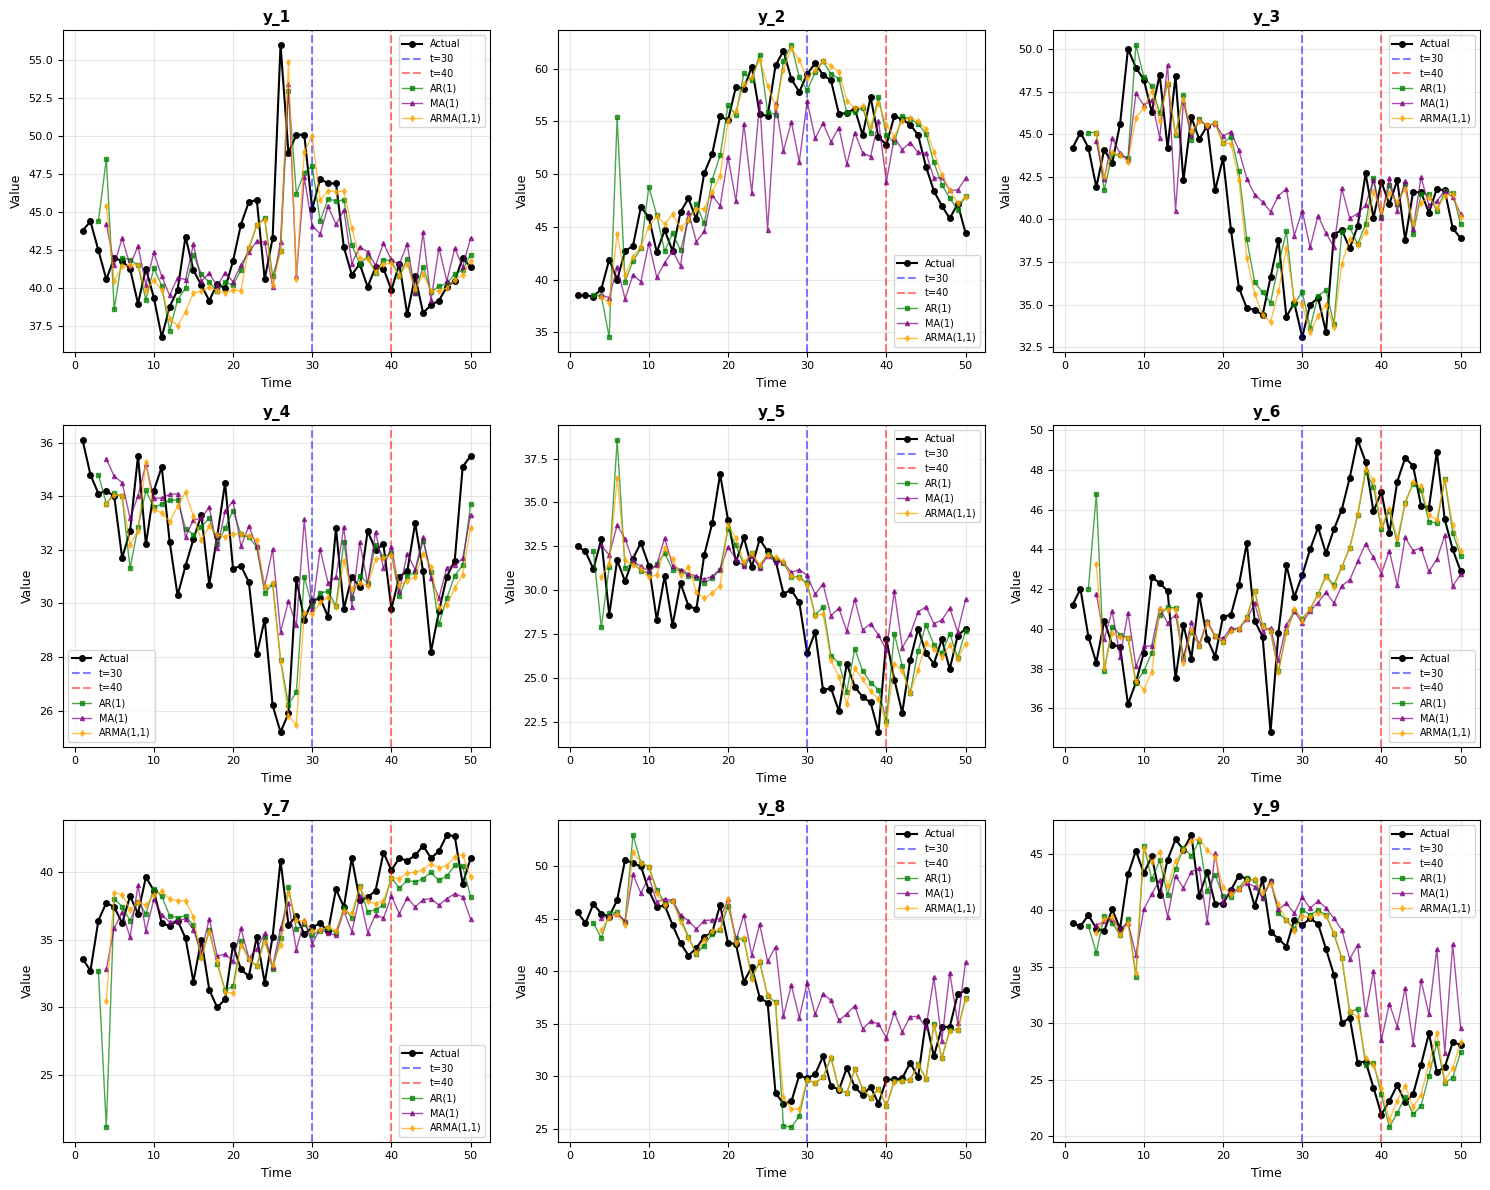

In [11]:
# Create plots for each series showing actual vs forecasts
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (name, y) in enumerate(zip(y_names, y_list)):
    ax = axes[i]
    
    # Generate rolling forecasts (Part 1 approach)
    f_ar1 = ar1_forecast(y)
    f_ma1 = ma1_forecast(y, criterion="SSE")
    f_arma = arma11_forecast(y, criterion="SSE")
    
    # Generate fixed forecasts for t=41..50 (Part 2 approach)
    y_40 = y[:40]
    mu_ar1, phi_ar1 = estimate_ar1_params(y_40)
    mu_ma1, theta_ma1 = estimate_ma1_params(y_40, criterion="SSE")
    c_arma, phi_arma, theta_arma = estimate_arma11_params(y_40, criterion="SSE")
    
    f_ar1_fix = fixed_ar1_one_step_forecasts(y, mu_ar1, phi_ar1, 40)
    f_ma1_fix = fixed_ma1_one_step_forecasts(y, mu_ma1, theta_ma1, 40)
    f_arma_fix = fixed_arma11_one_step_forecasts(y, c_arma, phi_arma, theta_arma, 40)
    
    # Combine: use rolling forecasts up to t=40, then fixed forecasts for t=41..50
    f_ar1_combined = np.copy(f_ar1)
    f_ma1_combined = np.copy(f_ma1)
    f_arma_combined = np.copy(f_arma)
    
    f_ar1_combined[40:] = f_ar1_fix[40:]
    f_ma1_combined[40:] = f_ma1_fix[40:]
    f_arma_combined[40:] = f_arma_fix[40:]
    
    # Plot actual values
    ax.plot(range(1, N+1), y, 'ko-', label='Actual', markersize=4, linewidth=1.5)
    
    # Add vertical lines to mark periods
    ax.axvline(x=30, color='blue', linestyle='--', alpha=0.5, linewidth=1.5, label='t=30')
    ax.axvline(x=40, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='t=40')
    
    # Plot forecasts for each method
    ax.plot(range(1, N+1), f_ar1_combined, 's-', color='green', 
            label='AR(1)', markersize=3, alpha=0.7, linewidth=1)
    ax.plot(range(1, N+1), f_ma1_combined, '^-', color='purple', 
            label='MA(1)', markersize=3, alpha=0.7, linewidth=1)
    ax.plot(range(1, N+1), f_arma_combined, 'd-', color='orange', 
            label='ARMA(1,1)', markersize=3, alpha=0.7, linewidth=1)
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('arma_forecasts_all_series.png', dpi=300, bbox_inches='tight')
plt.show()

## (d)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, probplot
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

# ----------------------------------------------------------------------
# 1. Functions to compute in‑sample one‑step‑ahead residuals
#    (using parameters estimated on the full series or a fixed training set)
# ----------------------------------------------------------------------

def compute_residuals_ar1(y, mu=None, phi=None):
    """
    Compute one-step-ahead forecast errors (residuals) for an AR(1) model.
    
    Parameters
    ----------
    y : array_like
        Time series.
    mu, phi : float, optional
        AR(1) parameters. If not provided, they are estimated from the entire series
        via linear regression (as in ar1_forecast).
    
    Returns
    -------
    residuals : np.ndarray
        Array of residuals, same length as y. First element is NaN.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan)
    
    if mu is None or phi is None:
        # Estimate parameters using the whole series
        y_dep = y[1:]
        y_lag = y[:-1].reshape(-1, 1)
        model = LinearRegression().fit(y_lag, y_dep)
        mu = model.intercept_
        phi = model.coef_[0]
    
    for t in range(1, n):
        residuals[t] = y[t] - (mu + phi * y[t-1])
    
    return residuals, mu, phi


def compute_residuals_ma1(y, mu=None, theta=None, criterion="SSE"):
    """
    Compute one-step-ahead forecast errors (residuals) for an MA(1) model.
    
    Parameters
    ----------
    y : array_like
        Time series.
    mu, theta : float, optional
        MA(1) parameters. If not provided, they are estimated by minimising
        the in‑sample SSE (or other criterion) on the entire series.
    criterion : str, optional
        Loss criterion passed to ma1_objective (default "SSE").
    
    Returns
    -------
    residuals : np.ndarray
        Array of residuals, same length as y. First element is NaN.
    mu, theta : float
        Estimated (or supplied) parameters.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan)
    
    if mu is None or theta is None:
        res = minimize(
            ma1_objective,
            [np.mean(y), 0.1],
            args=(y, criterion),
            bounds=[(None, None), (-1, 1)]
        )
        mu, theta = res.x
    
    eps = 0.0
    for t in range(n):
        if t == 0:
            residuals[t] = np.nan
        else:
            pred = mu + theta * eps
            residuals[t] = y[t] - pred
        eps = y[t] - (mu + theta * eps) if t < n-1 else 0  # update error for next step
    
    return residuals, mu, theta


def compute_residuals_arma11(y, c=None, phi=None, theta=None, criterion="SSE"):
    """
    Compute one-step-ahead forecast errors (residuals) for an ARMA(1,1) model.
    
    Parameters
    ----------
    y : array_like
        Time series.
    c, phi, theta : float, optional
        ARMA(1,1) parameters. If not provided, they are estimated by minimising
        the in‑sample SSE (or other criterion) on the entire series.
    criterion : str, optional
        Loss criterion passed to arma11_objective (default "SSE").
    
    Returns
    -------
    residuals : np.ndarray
        Array of residuals, same length as y. First element is NaN.
    c, phi, theta : float
        Estimated (or supplied) parameters.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan)
    
    if c is None or phi is None or theta is None:
        res = minimize(
            arma11_objective,
            [np.mean(y) * 0.1, 0.5, 0.1],
            args=(y, criterion),
            bounds=[(None, None), (-1, 1), (-1, 1)]
        )
        c, phi, theta = res.x
    
    eps = 0.0
    for t in range(1, n):
        pred = c + phi * y[t-1] + theta * eps
        residuals[t] = y[t] - pred
        eps = residuals[t]   # update the lagged error
    
    return residuals, c, phi, theta


# ----------------------------------------------------------------------
# 2. Diagnostic functions
# ----------------------------------------------------------------------

def residual_diagnostics(residuals, series_name, model_name, lags=10, figsize=(12, 4)):
    """
    Perform standard residual diagnostics: ACF, PACF, Ljung–Box test,
    and a Q-Q plot for normality. The number of lags is automatically
    reduced if it exceeds half the available sample size.

    Parameters
    ----------
    residuals : array_like
        One-step-ahead forecast errors (may contain NaN at the beginning).
    series_name : str
        Name of the time series (for plot titles).
    model_name : str
        Name of the model (AR(1), MA(1), ARMA(1,1)).
    lags : int, optional
        Requested number of lags. Will be capped to max(1, n_obs//2 - 1).
    figsize : tuple, optional
        Size of the figure.

    Returns
    -------
    lb_pvalue : float
        Ljung–Box test p-value at the (possibly reduced) lag.
    """
    # Remove leading NaN values (forecast errors for the first observation)
    res = residuals[~np.isnan(residuals)]
    n_obs = len(res)

    # Adjust lags if necessary
    max_safe_lags = n_obs // 2 - 1
    if lags > max_safe_lags:
        old_lags = lags
        lags = max(1, max_safe_lags)
        print(f"Warning: Requested lags={old_lags} exceeds half the sample size "
              f"({n_obs}). Using lags={lags} instead.")
    
    if n_obs < lags + 1:
        print(f"Error: Not enough observations ({n_obs}) for lags={lags}. Skipping plots.")
        return np.nan

    # Create diagnostic plots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # ACF
    plot_acf(res, ax=axes[0], lags=lags, title=f'ACF - {series_name} ({model_name})')
    axes[0].set_xlabel('Lag')
    
    # PACF (use Yule-Walker method which is standard for stationary series)
    plot_pacf(res, ax=axes[1], lags=lags, title=f'PACF - {series_name} ({model_name})',
              method='ywm')
    axes[1].set_xlabel('Lag')
    
    # Q-Q plot for normality
    probplot(res, dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot - {series_name} ({model_name})')
    axes[2].set_xlabel('Theoretical quantiles')
    axes[2].set_ylabel('Sample quantiles')
    
    plt.tight_layout()
    plt.show()
    
    # Ljung–Box test for residual autocorrelation
    lb_test = acorr_ljungbox(res, lags=[lags], return_df=True)
    lb_pvalue = lb_test.iloc[0, 1]   # p-value at the specified lag
    print(f"Ljung–Box test (lag={lags}): p-value = {lb_pvalue:.4f}")
    
    # Shapiro–Wilk test for normality (optional)
    shapiro_stat, shapiro_p = shapiro(res)
    print(f"Shapiro–Wilk test: p-value = {shapiro_p:.4f}")
    
    return lb_pvalue


def summarize_ljungbox_pvalues(results_dict):
    """
    Create a summary DataFrame of Ljung–Box p-values for quick comparison.
    
    Parameters
    ----------
    results_dict : dict
        Nested dictionary: results_dict[series_name][model_name] = p-value.
    
    Returns
    -------
    pd.DataFrame
        Rows: model names, Columns: series names.
    """
    df = pd.DataFrame(results_dict).T
    return df


Residual Diagnostics: Gasoline Sales 1


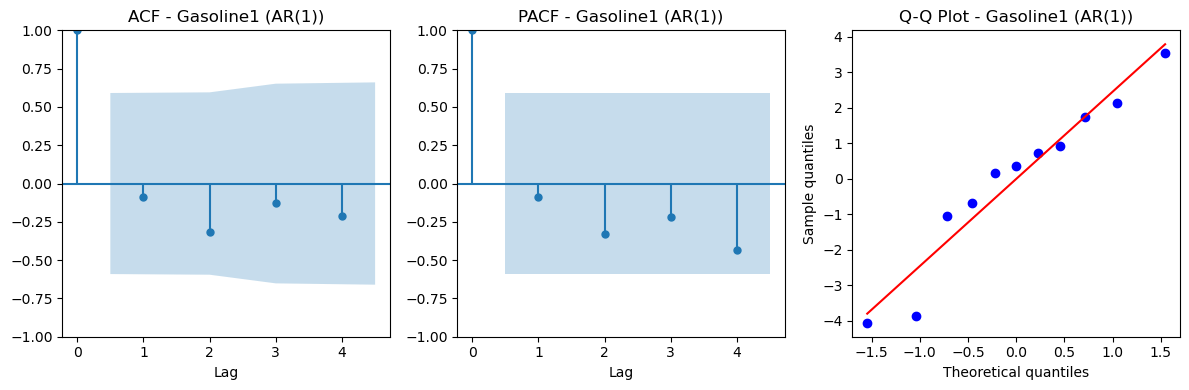

Ljung–Box test (lag=4): p-value = 0.5737
Shapiro–Wilk test: p-value = 0.4605


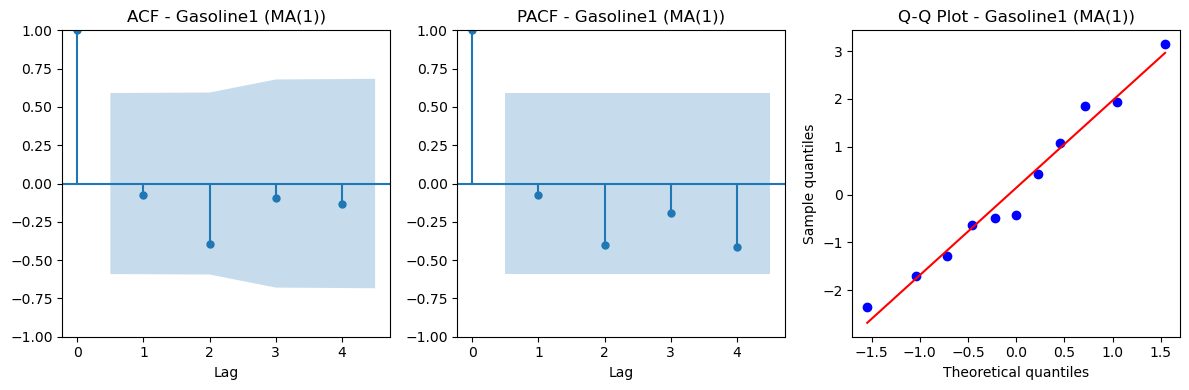

Ljung–Box test (lag=4): p-value = 0.5450
Shapiro–Wilk test: p-value = 0.8428


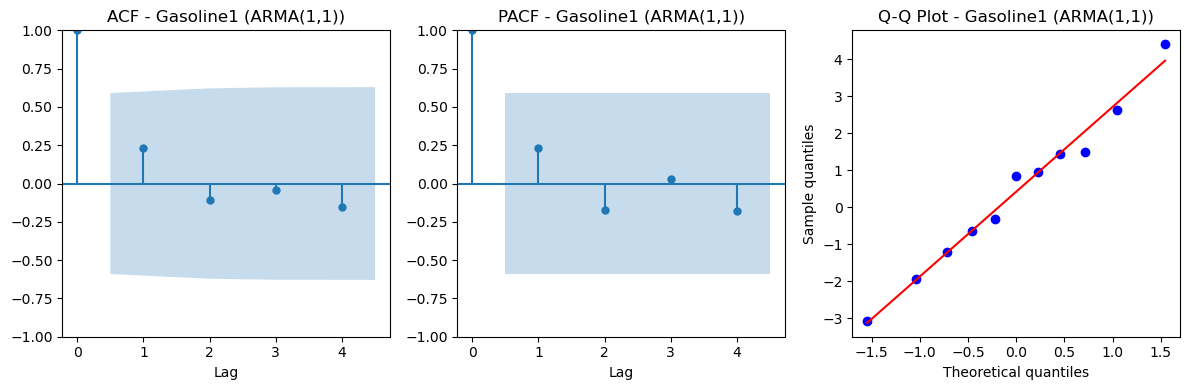

Ljung–Box test (lag=4): p-value = 0.8344
Shapiro–Wilk test: p-value = 0.9910

Residual Diagnostics: Gasoline Sales 2


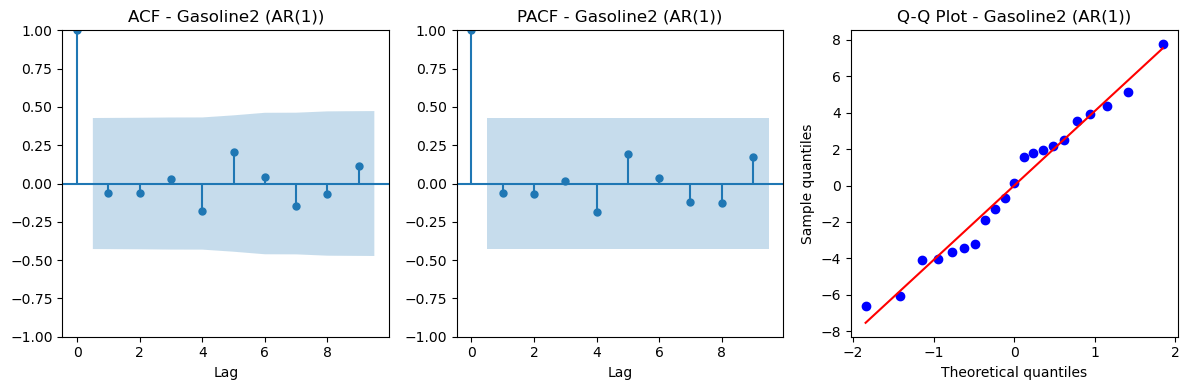

Ljung–Box test (lag=9): p-value = 0.9172
Shapiro–Wilk test: p-value = 0.7147


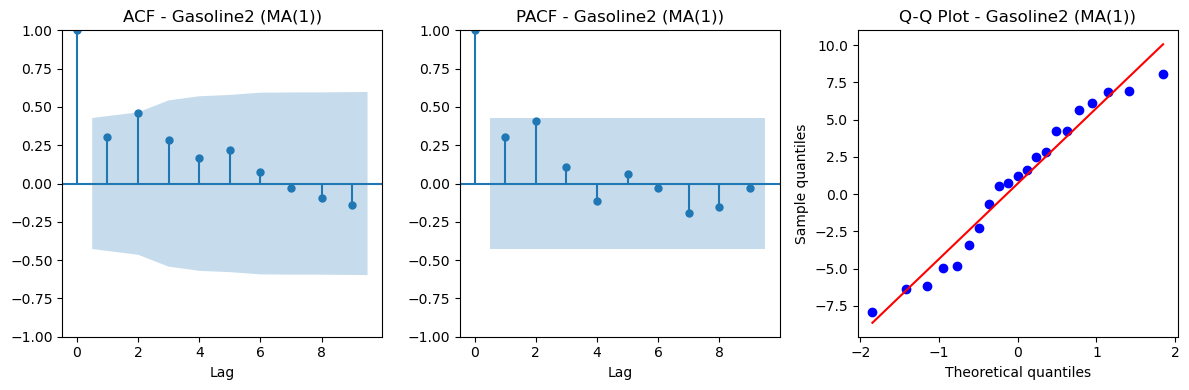

Ljung–Box test (lag=9): p-value = 0.1461
Shapiro–Wilk test: p-value = 0.3220


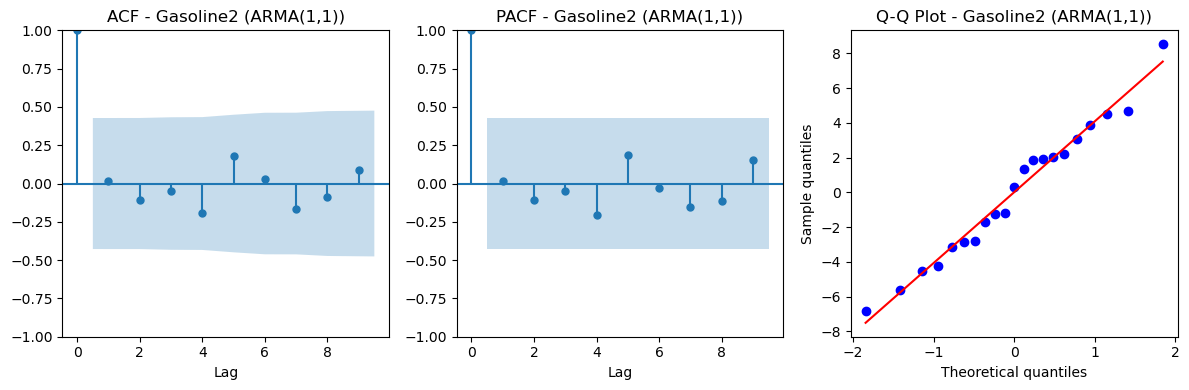

Ljung–Box test (lag=9): p-value = 0.9142
Shapiro–Wilk test: p-value = 0.8817


0.9141548688207335

In [14]:
# Gasoline 1
print("\n" + "="*60)
print("Residual Diagnostics: Gasoline Sales 1")
print("="*60)

y_g1 = y_gas1   

# AR(1)
res_ar1, mu_ar1, phi_ar1 = compute_residuals_ar1(y_g1)
lb_p = residual_diagnostics(res_ar1, "Gasoline1", "AR(1)", lags=10)

# MA(1)
res_ma1, mu_ma1, theta_ma1 = compute_residuals_ma1(y_g1)
lb_p = residual_diagnostics(res_ma1, "Gasoline1", "MA(1)", lags=10)

# ARMA(1,1)
res_arma, c_arma, phi_arma, theta_arma = compute_residuals_arma11(y_g1)
lb_p = residual_diagnostics(res_arma, "Gasoline1", "ARMA(1,1)", lags=10)

# Gasoline 2
print("\n" + "="*60)
print("Residual Diagnostics: Gasoline Sales 2")
print("="*60)

y_g2 = y_gas2   

res_ar1, _, _ = compute_residuals_ar1(y_g2)
residual_diagnostics(res_ar1, "Gasoline2", "AR(1)", lags=10)

res_ma1, _, _ = compute_residuals_ma1(y_g2)
residual_diagnostics(res_ma1, "Gasoline2", "MA(1)", lags=10)

res_arma, _, _, _ = compute_residuals_arma11(y_g2)
residual_diagnostics(res_arma, "Gasoline2", "ARMA(1,1)", lags=10)


Residual Diagnostics: Bicycle Sales


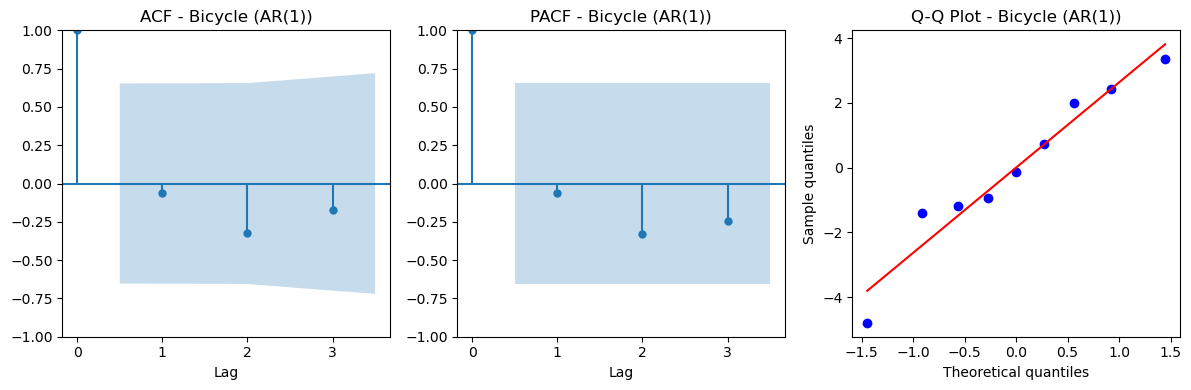

Ljung–Box test (lag=3): p-value = 0.5676
Shapiro–Wilk test: p-value = 0.7192


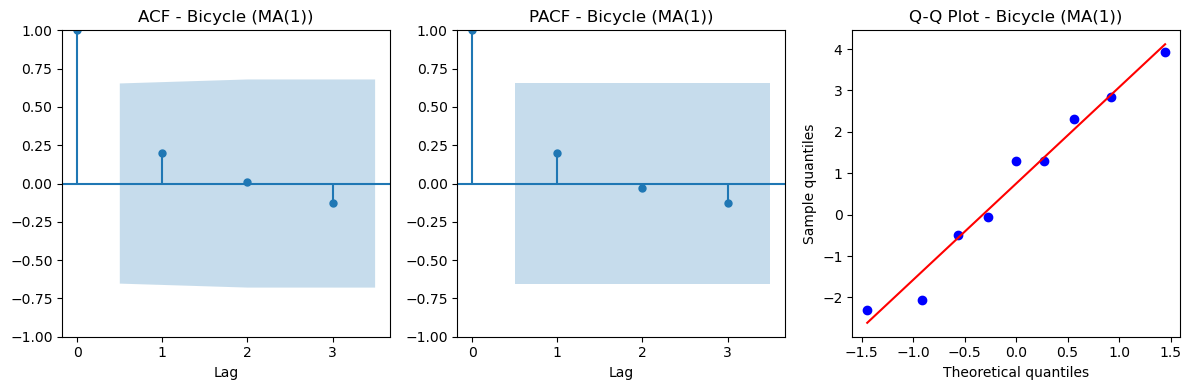

Ljung–Box test (lag=3): p-value = 0.8588
Shapiro–Wilk test: p-value = 0.7610


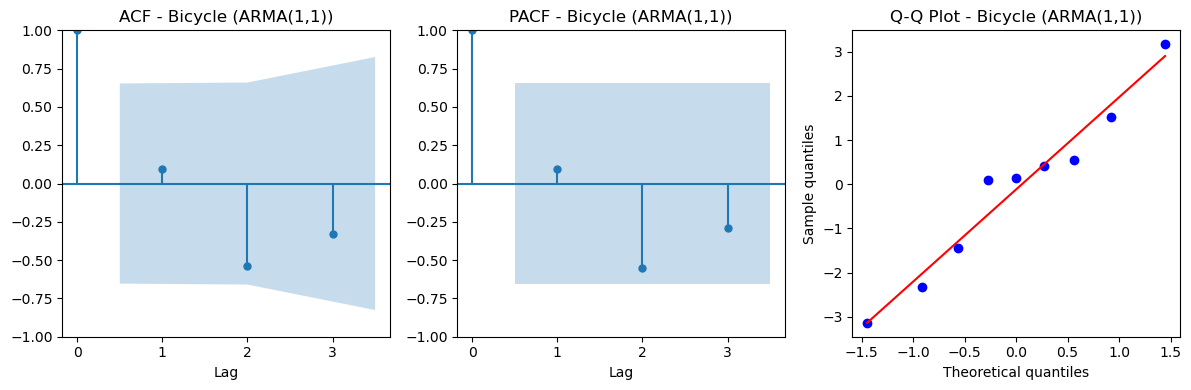

Ljung–Box test (lag=3): p-value = 0.1100
Shapiro–Wilk test: p-value = 0.8371


0.11000531434486162

In [15]:
print("\n" + "="*60)
print("Residual Diagnostics: Bicycle Sales")
print("="*60)

y_bike = y_bike  

res_ar1, _, _ = compute_residuals_ar1(y_bike)
residual_diagnostics(res_ar1, "Bicycle", "AR(1)", lags=10)

res_ma1, _, _ = compute_residuals_ma1(y_bike)
residual_diagnostics(res_ma1, "Bicycle", "MA(1)", lags=10)

res_arma, _, _, _ = compute_residuals_arma11(y_bike)
residual_diagnostics(res_arma, "Bicycle", "ARMA(1,1)", lags=10)


Residual Diagnostics: 9 Series from DataAssignment1 (first 40 obs)


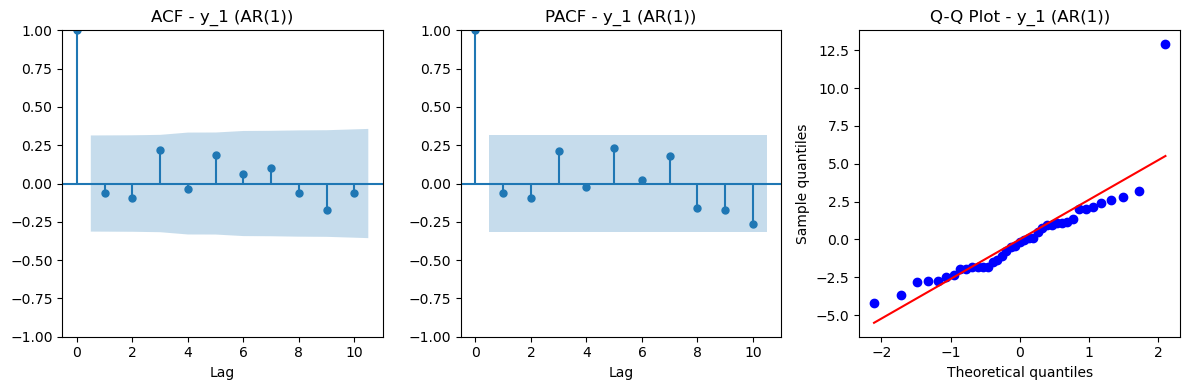

Ljung–Box test (lag=10): p-value = 0.7162
Shapiro–Wilk test: p-value = 0.0000


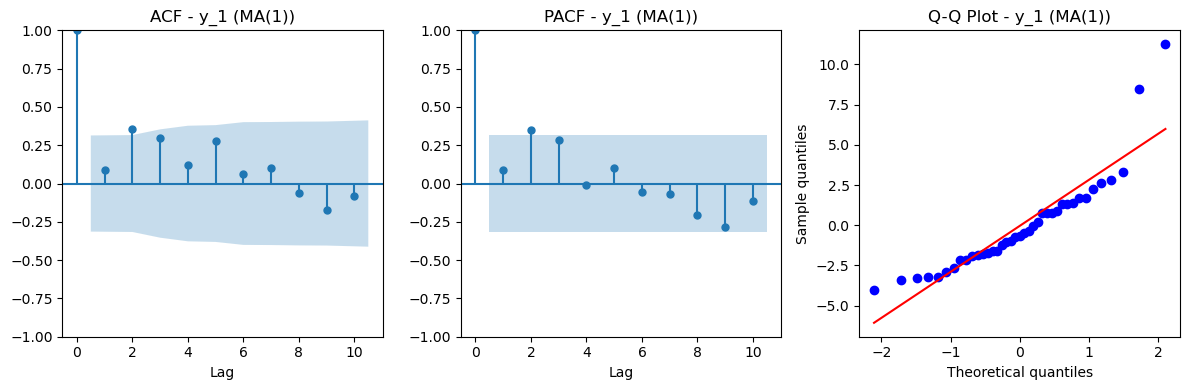

Ljung–Box test (lag=10): p-value = 0.0765
Shapiro–Wilk test: p-value = 0.0001


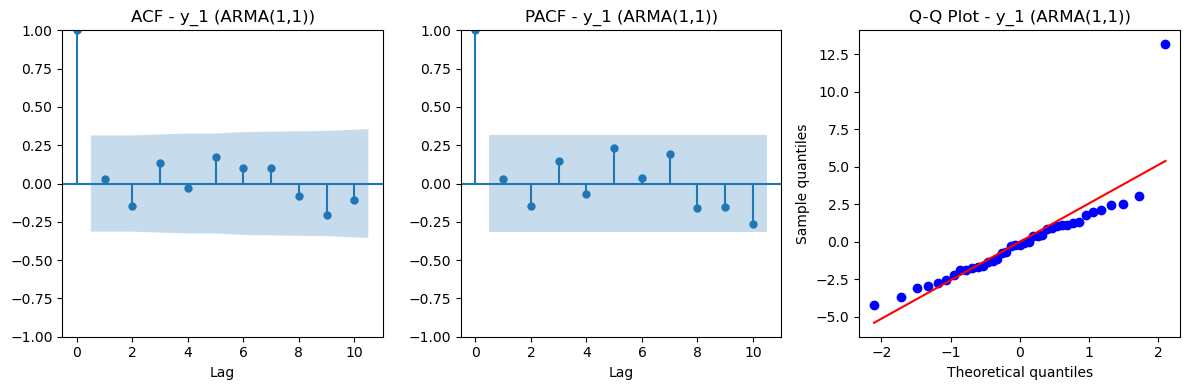

Ljung–Box test (lag=10): p-value = 0.6784
Shapiro–Wilk test: p-value = 0.0000


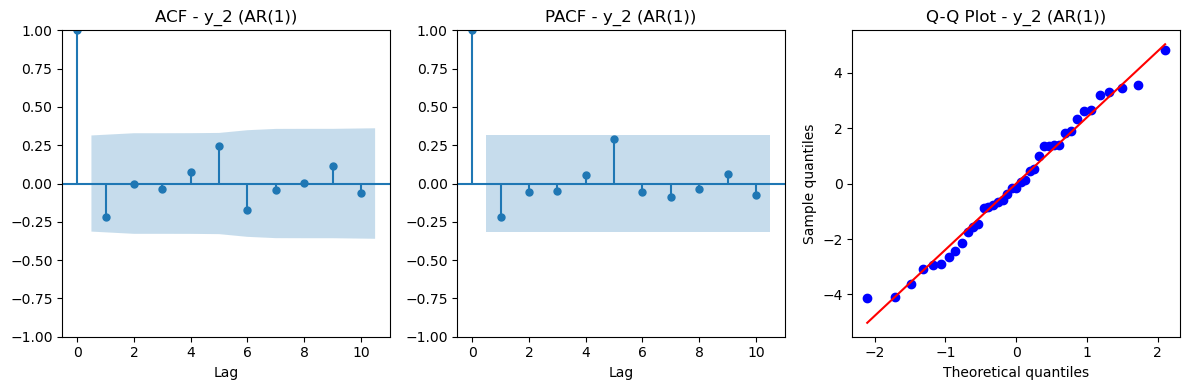

Ljung–Box test (lag=10): p-value = 0.6644
Shapiro–Wilk test: p-value = 0.6381


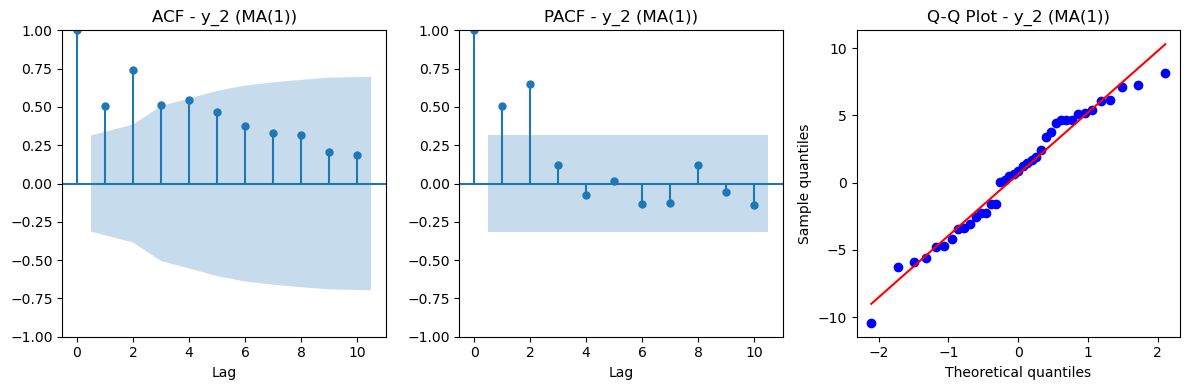

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.3390


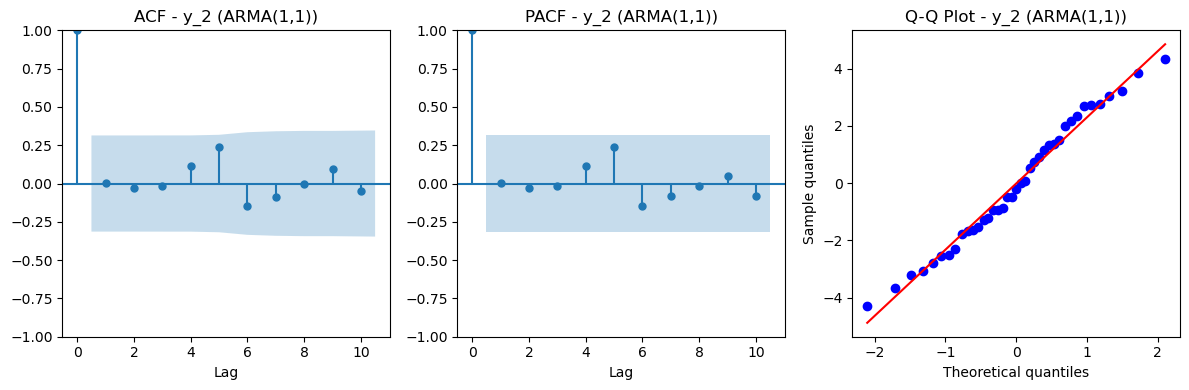

Ljung–Box test (lag=10): p-value = 0.8670
Shapiro–Wilk test: p-value = 0.5561


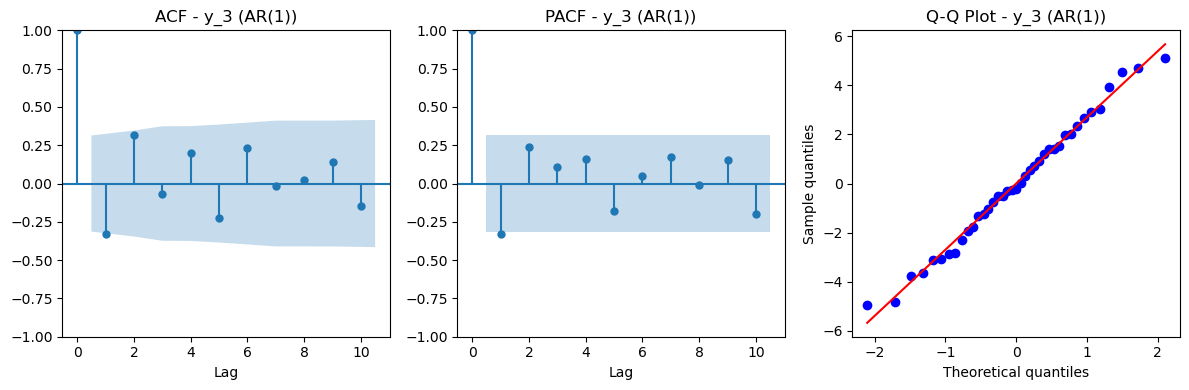

Ljung–Box test (lag=10): p-value = 0.0539
Shapiro–Wilk test: p-value = 0.8159


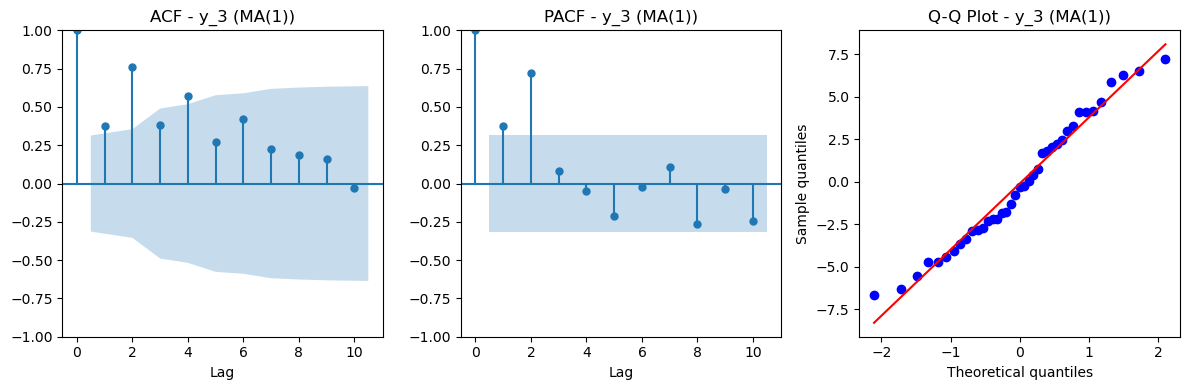

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.3359


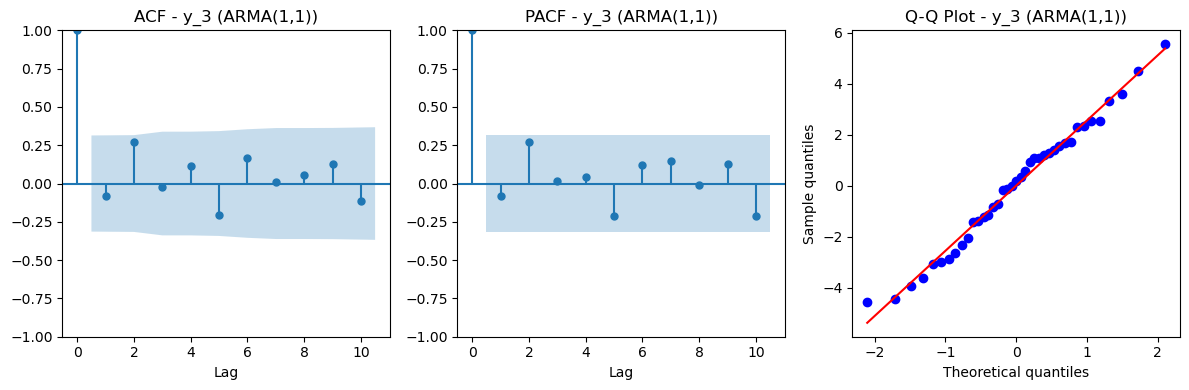

Ljung–Box test (lag=10): p-value = 0.5041
Shapiro–Wilk test: p-value = 0.7964


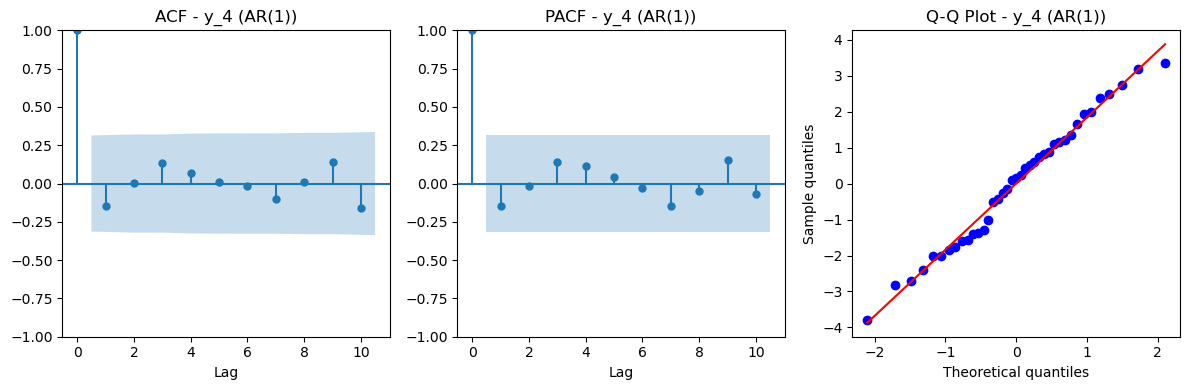

Ljung–Box test (lag=10): p-value = 0.8947
Shapiro–Wilk test: p-value = 0.7448


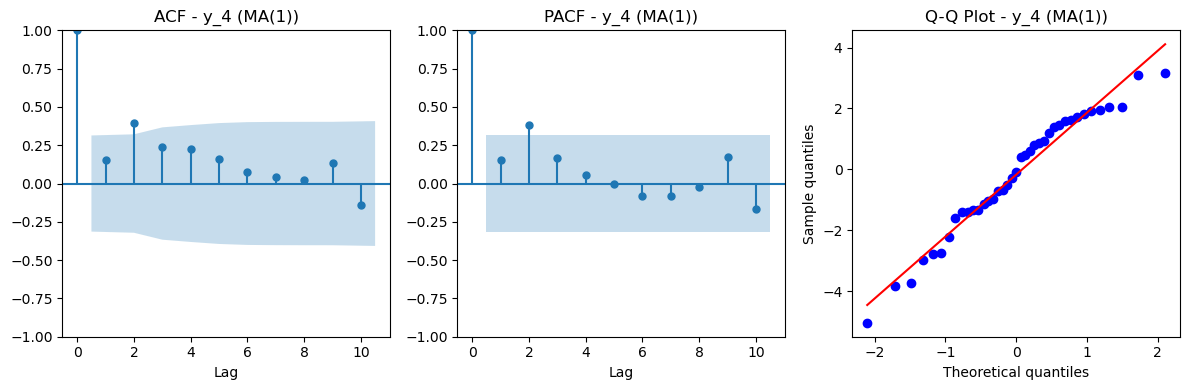

Ljung–Box test (lag=10): p-value = 0.0897
Shapiro–Wilk test: p-value = 0.2291


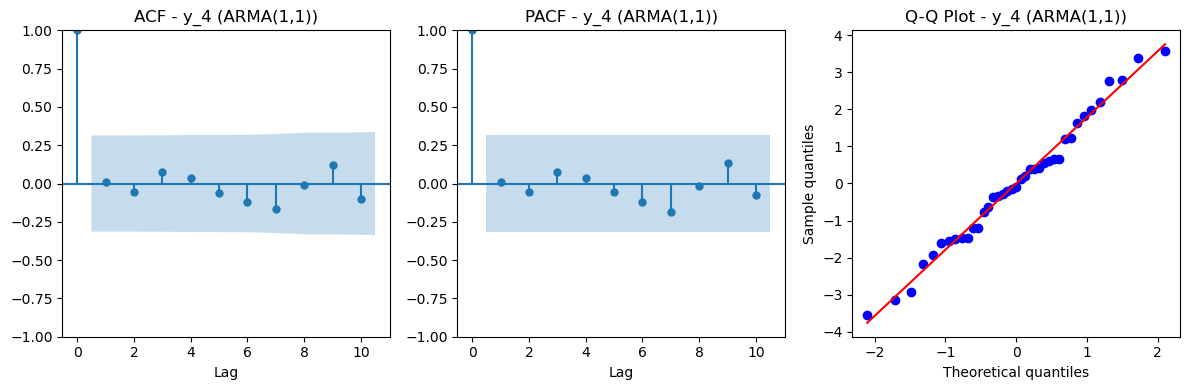

Ljung–Box test (lag=10): p-value = 0.9404
Shapiro–Wilk test: p-value = 0.8474


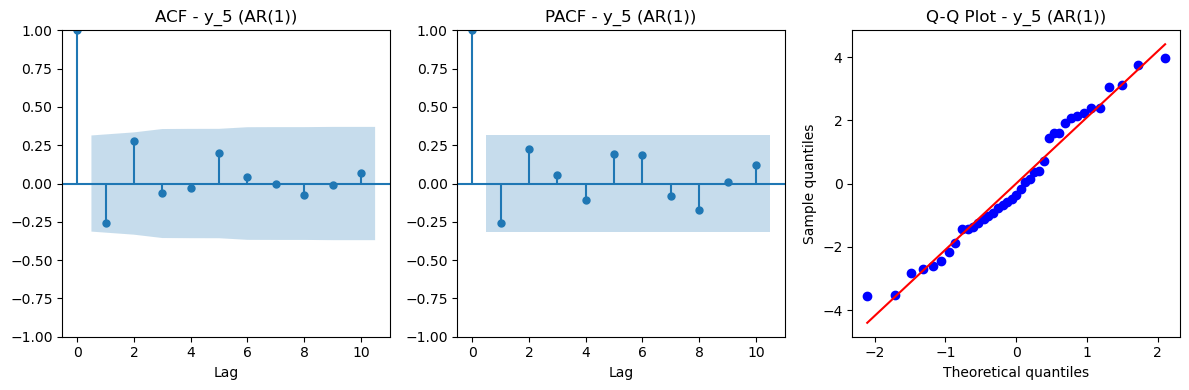

Ljung–Box test (lag=10): p-value = 0.5552
Shapiro–Wilk test: p-value = 0.3228


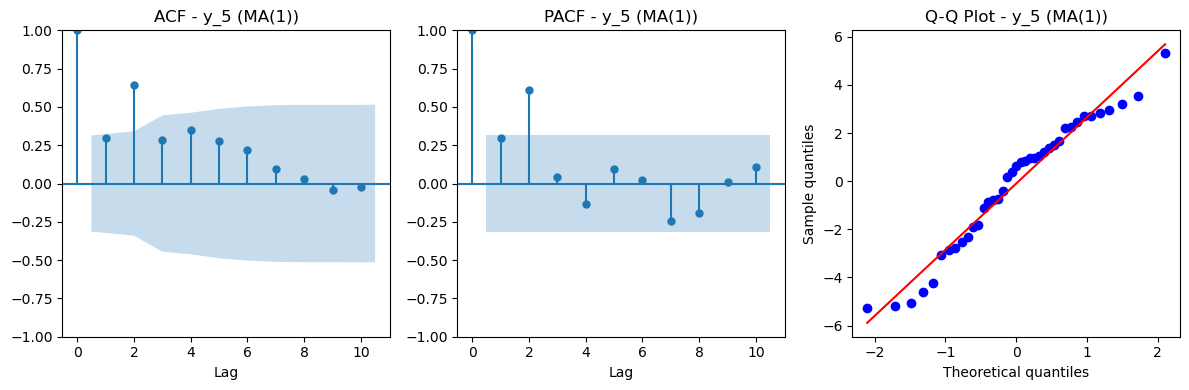

Ljung–Box test (lag=10): p-value = 0.0001
Shapiro–Wilk test: p-value = 0.1880


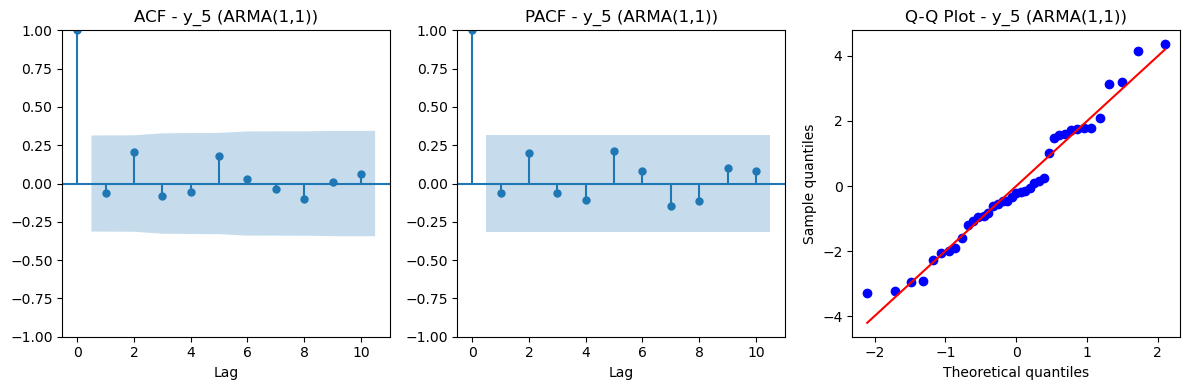

Ljung–Box test (lag=10): p-value = 0.9061
Shapiro–Wilk test: p-value = 0.2960


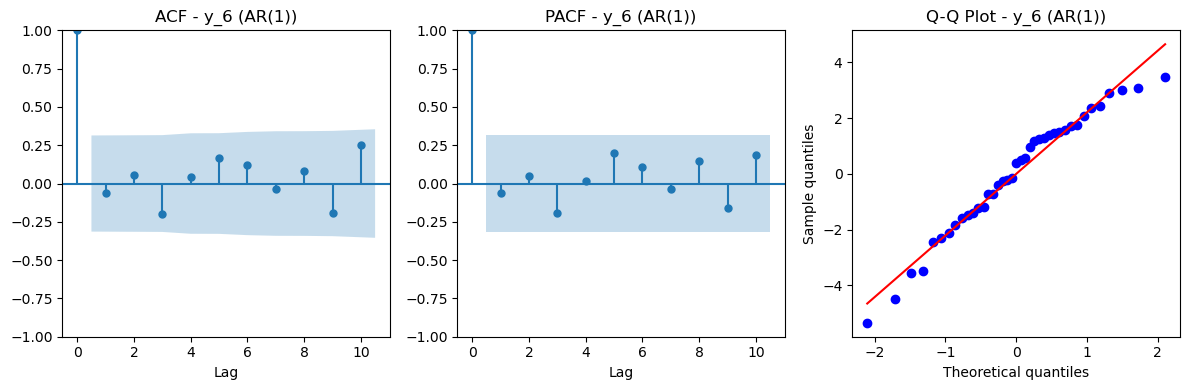

Ljung–Box test (lag=10): p-value = 0.4324
Shapiro–Wilk test: p-value = 0.2685


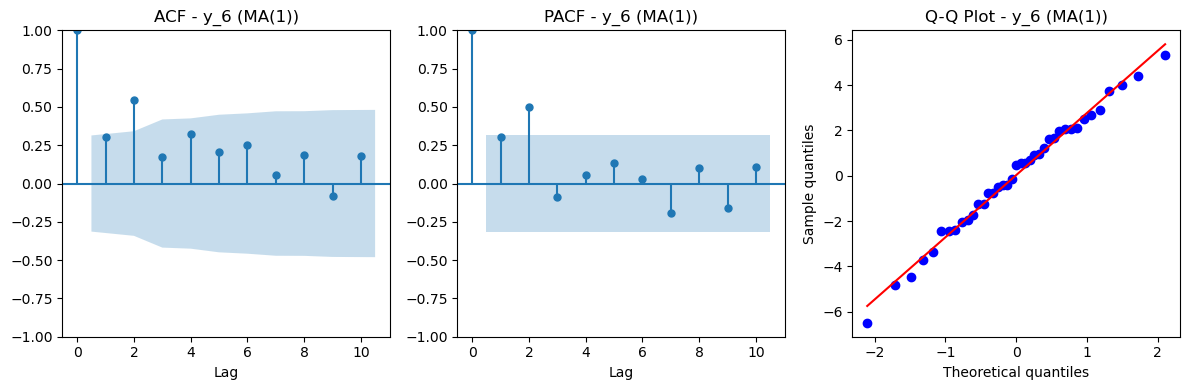

Ljung–Box test (lag=10): p-value = 0.0004
Shapiro–Wilk test: p-value = 0.9747


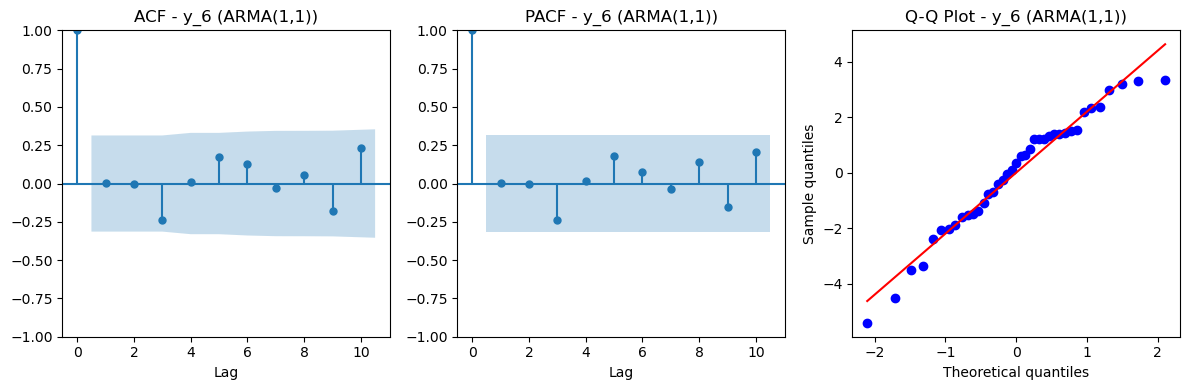

Ljung–Box test (lag=10): p-value = 0.4894
Shapiro–Wilk test: p-value = 0.2336


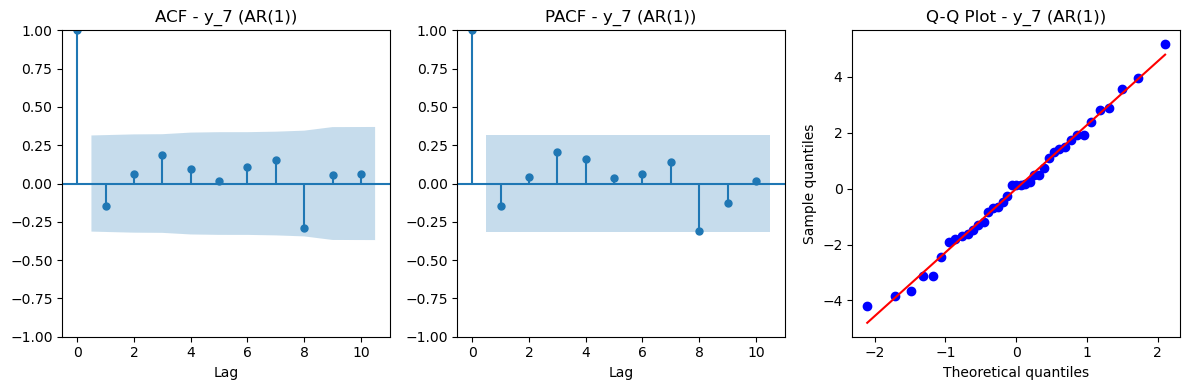

Ljung–Box test (lag=10): p-value = 0.4837
Shapiro–Wilk test: p-value = 0.9659


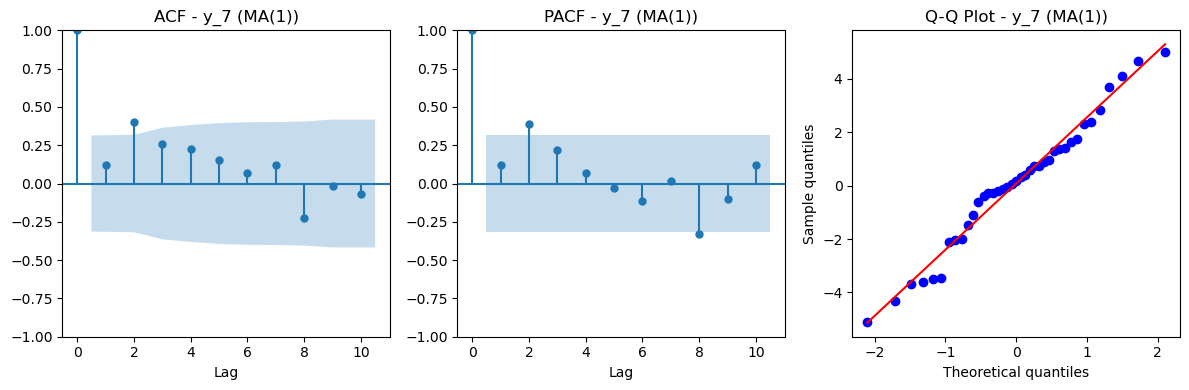

Ljung–Box test (lag=10): p-value = 0.0601
Shapiro–Wilk test: p-value = 0.5609


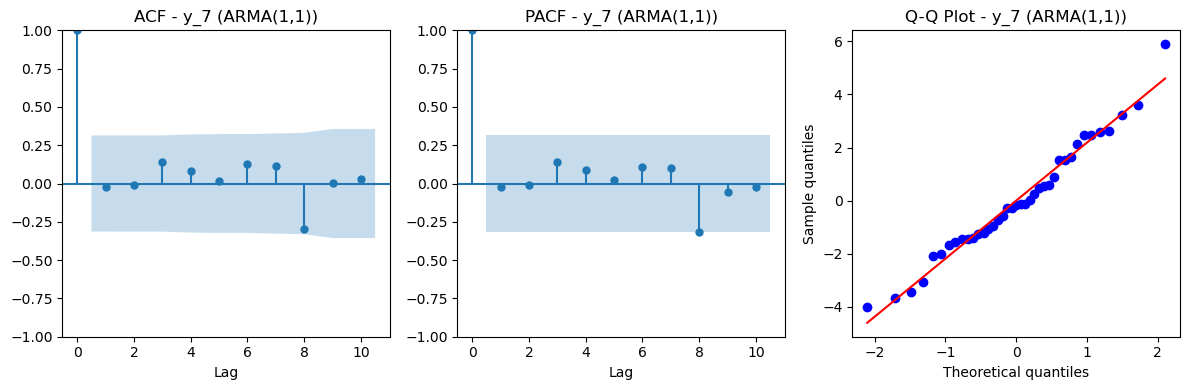

Ljung–Box test (lag=10): p-value = 0.7028
Shapiro–Wilk test: p-value = 0.6194


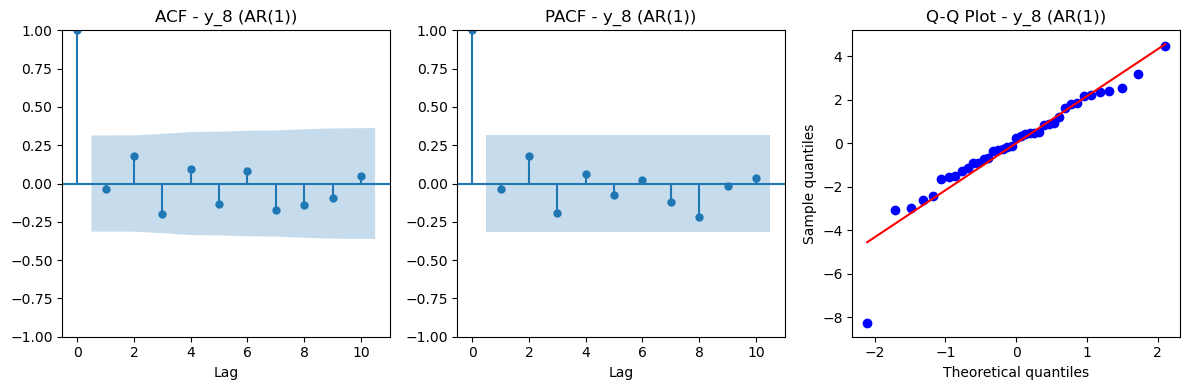

Ljung–Box test (lag=10): p-value = 0.6372
Shapiro–Wilk test: p-value = 0.0117


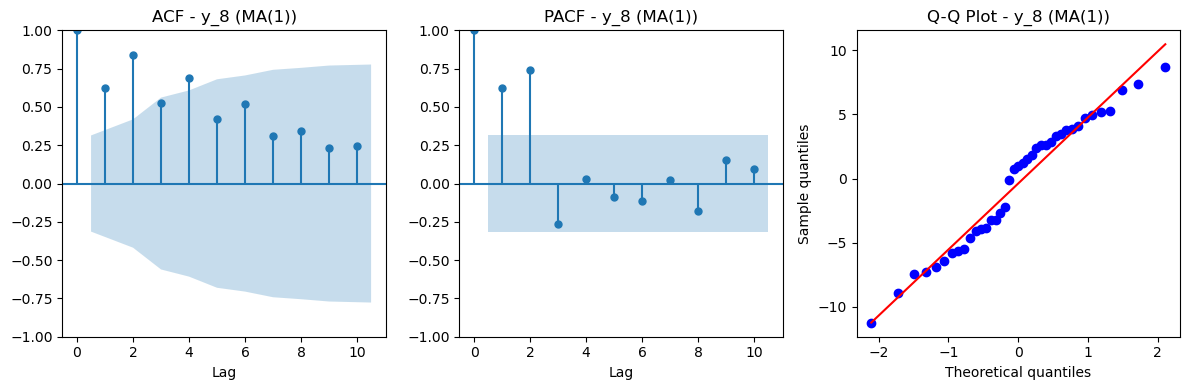

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.1659


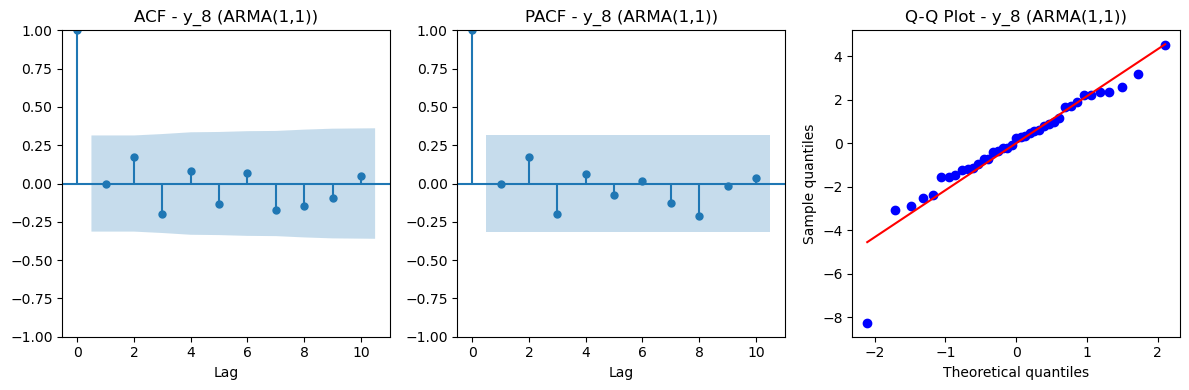

Ljung–Box test (lag=10): p-value = 0.6577
Shapiro–Wilk test: p-value = 0.0123


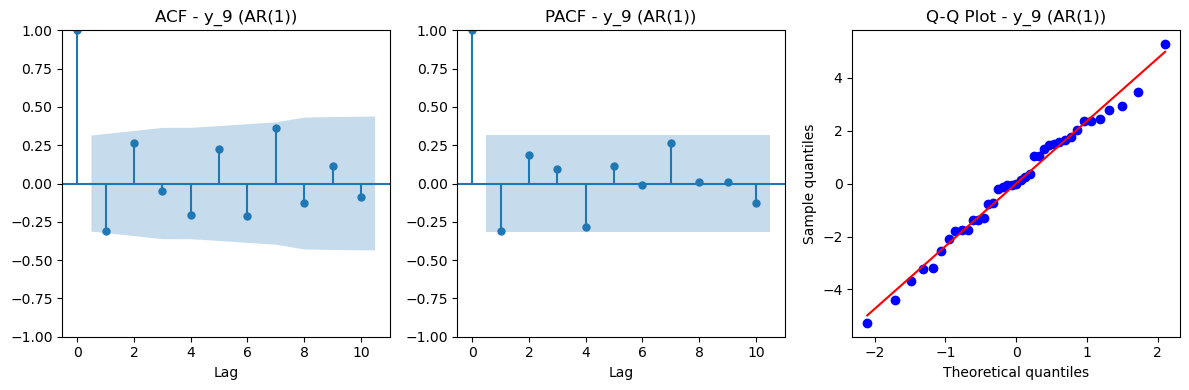

Ljung–Box test (lag=10): p-value = 0.0139
Shapiro–Wilk test: p-value = 0.9428


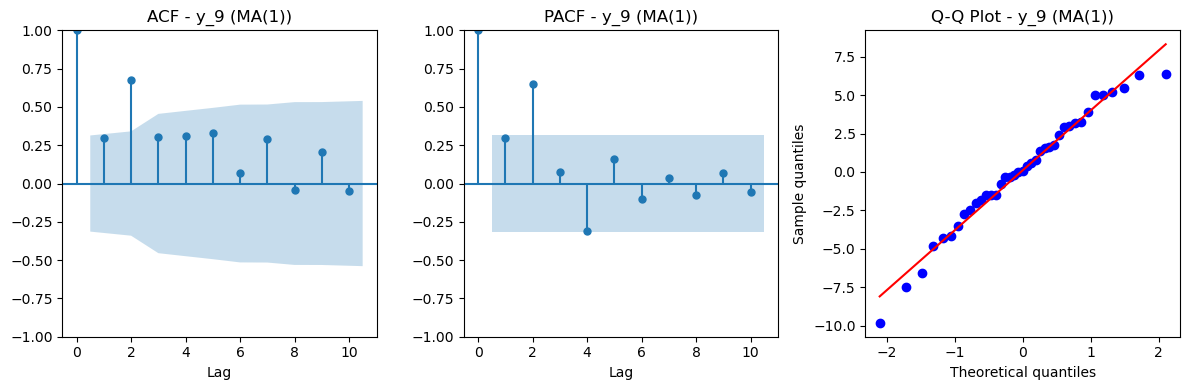

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.5493


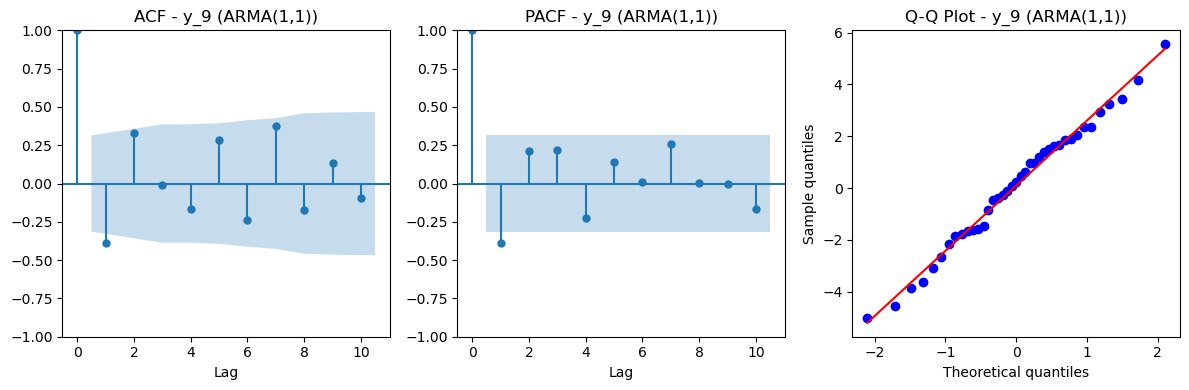

Ljung–Box test (lag=10): p-value = 0.0013
Shapiro–Wilk test: p-value = 0.9571

Ljung–Box p-values (lag=10) for the 9 series (training sample 1–40):


,AR(1),MA(1),"ARMA(1,1)"
y_1,0.716188,7.651316e-02,0.678378
y_2,0.664353,3.137324e-15,0.867018
y_3,0.053883,4.147817e-11,0.504077
y_4,0.894687,8.965962e-02,0.940391
y_5,0.555156,5.001238e-05,0.906133
y_6,0.432386,4.129899e-04,0.489412
y_7,0.483744,6.009958e-02,0.702828
y_8,0.637242,6.796895e-21,0.657666
y_9,0.013853,3.269186e-06,0.001331


In [17]:
print("\n" + "="*60)
print("Residual Diagnostics: 9 Series from DataAssignment1 (first 40 obs)")
print("="*60)

pvalue_dict = {}

for name, y in zip(y_names, y_list):
    y_train = y[:40]   # estimation sample
    pvalue_dict[name] = {}
    
    # AR(1)
    res_ar1, _, _ = compute_residuals_ar1(y_train)
    lb_p = residual_diagnostics(res_ar1, name, "AR(1)", lags=10)
    pvalue_dict[name]["AR(1)"] = lb_p
    
    # MA(1)
    res_ma1, _, _ = compute_residuals_ma1(y_train)
    lb_p = residual_diagnostics(res_ma1, name, "MA(1)", lags=10)
    pvalue_dict[name]["MA(1)"] = lb_p
    
    # ARMA(1,1)
    res_arma, _, _, _ = compute_residuals_arma11(y_train)
    lb_p = residual_diagnostics(res_arma, name, "ARMA(1,1)", lags=10)
    pvalue_dict[name]["ARMA(1,1)"] = lb_p

# Create summary table of Ljung–Box p-values
df_lb = summarize_ljungbox_pvalues(pvalue_dict)
print("\nLjung–Box p-values (lag=10) for the 9 series (training sample 1–40):")
display(df_lb)

## （e）

In [18]:
def align_h2_forecasts(y, forecast_from_origin_fn):
    """
    Returns f2 where f2[t+2] = yhat_{t+2|t}.
    forecast_from_origin_fn(y, t) must return the scalar 2-step forecast made at origin t
    using data up to and including y[t].
    """
    y = np.asarray(y, dtype=float)
    f2 = np.full(len(y), np.nan)
    for t in range(len(y) - 2):
        f2[t+2] = forecast_from_origin_fn(y, t)
    return f2

def rw_h2_origin(y, t):
    return y[t]

def rw_forecast_h2(y):
    return align_h2_forecasts(y, rw_h2_origin)

def running_avg_h2_origin(y, t):
    return np.mean(y[:t+1])

def running_average_forecast_h2(y):
    return align_h2_forecasts(y, running_avg_h2_origin)

def exp_smoothing_forecast_h2(y, alpha=0.2):
    y = np.asarray(y, dtype=float)
    f2 = np.full(len(y), np.nan)
    S = np.nan
    for t in range(len(y)):
        if t == 0:
            S = y[0]
        else:
            S = alpha * y[t] + (1 - alpha) * S
        # forecast made at t is used for t+2
        if t + 2 < len(y):
            f2[t+2] = S
    return f2

In [19]:
def ar1_h2_origin(y, t):
    # Need at least two points to regress y_1..y_t on y_0..y_{t-1}
    if t < 1:
        return np.nan
    y_past = y[:t+1]
    y_dep = y_past[1:]
    y_lag = y_past[:-1].reshape(-1, 1)
    model = LinearRegression().fit(y_lag, y_dep)
    c = float(model.intercept_)
    phi = float(model.coef_[0])

    yhat1 = c + phi * y[t]
    yhat2 = c + phi * yhat1
    return yhat2

def ar1_forecast_h2(y):
    return align_h2_forecasts(y, ar1_h2_origin)

In [20]:
def ma1_objective(params, y_hist):
    mu, theta = params
    eps = 0.0
    sse = 0.0
    for val in y_hist:
        err = val - (mu + theta * eps)
        sse += err**2
        eps = err
    return sse

def ma1_h2_origin(y, t):
    # Fit using data up to y[t]
    y_hist = y[:t+1]
    if len(y_hist) < 3:
        return np.nan
    res = minimize(
        ma1_objective,
        x0=[np.mean(y_hist), 0.1],
        args=(y_hist,),
        bounds=[(None, None), (-1, 1)]
    )
    mu, theta = res.x
    # 2-step forecast for MA(1) equals mu
    return float(mu)

def ma1_forecast_h2(y):
    return align_h2_forecasts(y, ma1_h2_origin)


In [21]:
def arma11_objective(params, y_hist):
    c, phi, theta = params
    eps = 0.0
    sse = 0.0
    for i in range(1, len(y_hist)):
        f_i = c + phi * y_hist[i-1] + theta * eps
        eps = y_hist[i] - f_i
        sse += eps**2
    return sse

def arma11_h2_origin(y, t):
    y_hist = y[:t+1]
    if len(y_hist) < 3:
        return np.nan
    res = minimize(
        arma11_objective,
        x0=[0.0, 0.5, 0.1],
        args=(y_hist,),
        bounds=[(None, None), (-1, 1), (-1, 1)]
    )
    c, phi, theta = res.x

    # compute last residual eps_t using fitted parameters
    eps = 0.0
    for i in range(1, len(y_hist)):
        f_i = c + phi * y_hist[i-1] + theta * eps
        eps = y_hist[i] - f_i

    yhat1 = c + phi * y[t] + theta * eps
    yhat2 = c + phi * yhat1
    return float(yhat2)

def arma11_forecast_h2(y):
    return align_h2_forecasts(y, arma11_h2_origin)


In [22]:
def eval_h2(y, f2, start=0):
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(f2)
    mask[:start] = False
    return metrics(y[mask], f2[mask])

In [23]:
def compare_methods_h2(y, start=0):
    """
    Apply all h=2 forecast methods to a single series y
    and return a comparison table sorted by MSE.
    """
    results = {}

    f2_rw   = rw_forecast_h2(y)
    f2_ra   = running_average_forecast_h2(y)
    f2_es   = exp_smoothing_forecast_h2(y, alpha=0.2)
    f2_ar1  = ar1_forecast_h2(y)
    f2_ma1  = ma1_forecast_h2(y)
    f2_arma = arma11_forecast_h2(y)

    methods = {
        "Random Walk (h=2)": f2_rw,
        "Running Average (h=2)": f2_ra,
        "Exp. Smoothing (0.2, h=2)": f2_es,
        "AR(1) (h=2)": f2_ar1,
        "MA(1) (h=2)": f2_ma1,
        "ARMA(1,1) (h=2)": f2_arma
    }

    for name, f2 in methods.items():
        me, mae, mape, mse = eval_h2(y, f2, start=start)
        results[name] = [me, mae, mape, mse]

    df = pd.DataFrame(
        results,
        index=["ME", "MAE", "MAPE", "MSE"]
    ).T

    return df.sort_values("MSE")


In [24]:
# Gasoline Sales 1
df_h2_gas1 = compare_methods_h2(y_gas1)
print("Gasoline Sales 1 – h=2 Forecast Comparison")
display(df_h2_gas1)

# Gasoline Sales 2
df_h2_gas2 = compare_methods_h2(y_gas2)
print("Gasoline Sales 2 – h=2 Forecast Comparison")
display(df_h2_gas2)

# Bicycle Sales
df_h2_bike = compare_methods_h2(y_bike)
print("Bicycle Sales – h=2 Forecast Comparison")
display(df_h2_bike)


Gasoline Sales 1 – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
MA(1) (h=2),-0.386495,2.079391,11.658007,6.024999
Running Average (h=2),0.252381,2.319048,12.472281,7.286104
AR(1) (h=2),-0.435346,2.330508,12.998770,7.635344
"Exp. Smoothing (0.2, h=2)",0.840597,2.344966,12.257702,8.004018
"ARMA(1,1) (h=2)",-0.264236,2.479085,14.179973,8.981472
Random Walk (h=2),-0.100000,2.900000,16.448712,12.700000


Gasoline Sales 2 – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
Random Walk (h=2),1.450000,3.750000,15.458057,29.150000
AR(1) (h=2),2.559847,3.992455,15.134547,31.576807
"Exp. Smoothing (0.2, h=2)",3.769938,4.522123,16.558356,35.826530
"ARMA(1,1) (h=2)",3.670854,5.011584,18.551527,42.186286
Running Average (h=2),4.994302,6.027635,21.539506,54.663764
MA(1) (h=2),5.384636,6.480585,22.660831,61.830781


Bicycle Sales – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
Random Walk (h=2),1.937500,3.312500,11.750849,15.503750
Running Average (h=2),4.033051,4.120551,14.132104,23.345173
"Exp. Smoothing (0.2, h=2)",4.209022,4.209022,14.475871,24.261125
"ARMA(1,1) (h=2)",2.144694,4.648559,16.247568,25.495837
MA(1) (h=2),4.874396,4.874396,16.369815,29.485533
AR(1) (h=2),-0.551895,6.274823,23.301103,63.874951


In [ ]:
# df_da1 = pd.read_excel("DataAssignment1.xlsx")

# all_results = []

# for col in df_da1.columns:
#     y = df_da1[col].values
#     df_one = compare_methods_h2(y)
#     df_one["Series"] = col
#     all_results.append(df_one)

# df_all = pd.concat(all_results)

# # Average performance across 9 series
# summary_da1_h2 = (
#     df_all
#     .groupby(df_all.index)[["ME", "MAE", "MAPE", "MSE"]]
#     .mean()
#     .sort_values("MSE")
# )

# print("DataAssignment1 – Average h=2 Forecast Performance (9 Series)")
# display(summary_da1_h2)


DataAssignment1 – Average h=2 Forecast Performance (9 Series)


,ME,MAE,MAPE,MSE
Random Walk (h=2),-0.066435,2.154398,5.751446,7.912894
"ARMA(1,1) (h=2)",-0.057195,2.360696,6.305662,9.416724
"Exp. Smoothing (0.2, h=2)",-0.242926,2.658545,7.216204,12.200767
Running Average (h=2),-0.734056,4.036601,11.325532,29.938724
MA(1) (h=2),-0.720853,4.174608,11.686575,31.563408
AR(1) (h=2),-0.362437,2.891141,7.728249,32.452563
